# Brazilian E-Commerce Public Dataset — End-to-End Analysis

> **Dataset:** [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
> **Author:** *Berliani Risqi*  
> **Date:** 2026

---

## 📋 Daftar Isi
1. [Business Questions](#1-business-questions)
2. [Data Wrangling](#2-data-wrangling)
   - 2.1 Gathering Data
   - 2.2 Assessing Data
   - 2.3 Cleaning Data
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Visualization & Explanatory Analysis](#4-visualization)
5. [Advanced Analysis: RFM + Geospatial + Clustering](#5-advanced)
6. [Conclusion & Recommendation](#6-conclusion)

---
## 1. Business Questions

Berikut adalah dua pertanyaan bisnis yang akan dijawab melalui proses analisis data. Keduanya memenuhi kriteria **SMART** (Specific, Measurable, Action-Oriented, Relevant, Time-bound).

---

### ❓ Pertanyaan Bisnis 1
> **"Kategori produk apa yang memiliki rata-rata review score tertinggi dan terendah, serta bagaimana pola pengiriman (rata-rata keterlambatan dalam hari) memengaruhi kepuasan pelanggan (review score) pada periode 2017–2018?"**

| Elemen SMART | Penjelasan |
|---|---|
| **Specific** | Fokus pada kategori produk dan keterlambatan pengiriman terhadap review score |
| **Measurable** | Menggunakan rata-rata review score (1–5) dan jumlah hari keterlambatan |
| **Action-Oriented** | Hasil dapat digunakan untuk memprioritaskan kategori produk dan memperbaiki SLA logistik |
| **Relevant** | Kepuasan pelanggan dan kecepatan pengiriman adalah KPI utama e-commerce |
| **Time-bound** | Dibatasi pada periode 2017–2018 sesuai rentang data utama |

---

### ❓ Pertanyaan Bisnis 2
> **"Bagaimana distribusi nilai transaksi (revenue) berdasarkan negara bagian (state) di Brasil selama tahun 2017–2018, dan state mana yang memiliki potensi pertumbuhan tertinggi berdasarkan jumlah order dan rata-rata nilai pembelian per pelanggan?"**

| Elemen SMART | Penjelasan |
|---|---|
| **Specific** | Fokus pada revenue dan jumlah order per state di Brasil |
| **Measurable** | Diukur dengan total revenue (BRL), jumlah order, dan rata-rata AOV (Average Order Value) |
| **Action-Oriented** | Membantu tim marketing menentukan alokasi anggaran ekspansi per wilayah |
| **Relevant** | Analisis geografis sangat relevan untuk strategi ekspansi bisnis e-commerce |
| **Time-bound** | Dibatasi pada periode 2017–2018 |


---
## 2. 🔧 Data Wrangling

### 2.1 Gathering Data

Pada tahap ini muat semua dataset yang diperlukan dari Kaggle ke dalam DataFrame pandas.

In [1]:
# INSTALL DEPENDENCIES
!pip install -q kaggle folium geopandas mapclassify

In [2]:
# ============================================================
# DOWNLOAD DATASET FROM KAGGLE
# Cara 1: Upload kaggle.json via Colab
# ============================================================
import os
from google.colab import files

# Upload kaggle.json (API token dari https://www.kaggle.com/settings)
print("Upload file kaggle.json Anda:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -q brazilian-ecommerce.zip -d data/
print(" Dataset berhasil diunduh!")

Upload file kaggle.json Anda:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 150MB/s]

 Dataset berhasil diunduh!


In [3]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2D6A4F', '#40916C', '#52B788', '#74C69D', '#B7E4C7',
           '#D8F3DC', '#F28A2E', '#E63946', '#457B9D', '#1D3557']
print(" Libraries loaded!")

 Libraries loaded!


In [5]:
# LOAD ALL CSV FILES INTO DATAFRAMES
path = 'data'
BASE = path + '/'

orders_df           = pd.read_csv(BASE + 'olist_orders_dataset.csv')
order_items_df      = pd.read_csv(BASE + 'olist_order_items_dataset.csv')
order_reviews_df    = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv')
order_payments_df   = pd.read_csv(BASE + 'olist_order_payments_dataset.csv')
customers_df        = pd.read_csv(BASE + 'olist_customers_dataset.csv')
products_df         = pd.read_csv(BASE + 'olist_products_dataset.csv')
sellers_df          = pd.read_csv(BASE + 'olist_sellers_dataset.csv')
geolocation_df      = pd.read_csv(BASE + 'olist_geolocation_dataset.csv')
product_category_df = pd.read_csv(BASE + 'product_category_name_translation.csv')

datasets = {
    'orders': orders_df,
    'order_items': order_items_df,
    'order_reviews': order_reviews_df,
    'order_payments': order_payments_df,
    'customers': customers_df,
    'products': products_df,
    'sellers': sellers_df,
    'geolocation': geolocation_df,
    'product_category': product_category_df
}

print(" Dataset yang berhasil dimuat:")
for name, df in datasets.items():
    print(f"  {name:25s} → {df.shape[0]:,} baris × {df.shape[1]} kolom")

 Dataset yang berhasil dimuat:
  orders                    → 99,441 baris × 8 kolom
  order_items               → 112,650 baris × 7 kolom
  order_reviews             → 99,224 baris × 7 kolom
  order_payments            → 103,886 baris × 5 kolom
  customers                 → 99,441 baris × 5 kolom
  products                  → 32,951 baris × 9 kolom
  sellers                   → 3,095 baris × 4 kolom
  geolocation               → 1,000,163 baris × 5 kolom
  product_category          → 71 baris × 2 kolom


### 2.2 Assessing Data

Pada tahap ini bertujuan untuk menilai kualitas data dari setiap tabel dan mengidentifikasi permasalahan yang perlu ditangani.

In [6]:
# FUNGSI HELPER: ASSESS DATAFRAME
def assess_df(df, name):
    print(f"\n{'='*60}")
    print(f" DATASET: {name.upper()}")
    print(f"{'='*60}")
    print(f"Shape      : {df.shape}")
    print(f"\n--- Tipe Data ---")
    print(df.dtypes)
    print(f"\n--- Missing Values ---")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    print(missing_df[missing_df['Missing Count'] > 0])
    print(f"\n--- Duplicate Rows ---")
    print(f"Jumlah duplikat: {df.duplicated().sum()}")
    print(f"\n--- Sample Data ---")
    display(df.head(3))

for name, df in datasets.items():
    assess_df(df, name)


 DATASET: ORDERS
Shape      : (99441, 8)

--- Tipe Data ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

--- Missing Values ---
                               Missing Count  Missing %
order_approved_at                        160       0.16
order_delivered_carrier_date            1783       1.79
order_delivered_customer_date           2965       2.98

--- Duplicate Rows ---
Jumlah duplikat: 0

--- Sample Data ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



 DATASET: ORDER_ITEMS
Shape      : (112650, 7)

--- Tipe Data ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

--- Missing Values ---
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

--- Duplicate Rows ---
Jumlah duplikat: 0

--- Sample Data ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



 DATASET: ORDER_REVIEWS
Shape      : (99224, 7)

--- Tipe Data ---
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

--- Missing Values ---
                        Missing Count  Missing %
review_comment_title            87656      88.34
review_comment_message          58247      58.70

--- Duplicate Rows ---
Jumlah duplikat: 0

--- Sample Data ---


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



 DATASET: GEOLOCATION
Shape      : (1000163, 5)

--- Tipe Data ---
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

--- Missing Values ---
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

--- Duplicate Rows ---
Jumlah duplikat: 261831

--- Sample Data ---


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



 DATASET: PRODUCT_CATEGORY
Shape      : (71, 2)

--- Tipe Data ---
product_category_name            object
product_category_name_english    object
dtype: object

--- Missing Values ---
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

--- Duplicate Rows ---
Jumlah duplikat: 0

--- Sample Data ---


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [7]:
# IDENTIFIKASI MASALAH SPESIFIK

# Masalah 1: Missing values pada orders (tanggal delivery)
print(" MASALAH 1: Missing Values pada orders_df")
print(orders_df[['order_approved_at','order_delivered_carrier_date',
                  'order_delivered_customer_date']].isnull().sum())

# Masalah 2: Missing product category names
print("\n MASALAH 2: Missing product_category_name pada products_df")
print(f"Jumlah missing: {products_df['product_category_name'].isnull().sum()}")

# Masalah 3: Duplikat di geolocation
print("\n MASALAH 3: Duplicate rows di geolocation_df")
print(f"Jumlah duplikat: {geolocation_df.duplicated().sum()}")

# Masalah 4: Outlier pada review comments
print("\n MASALAH 4: Invalid value — orders dengan status 'delivered' tapi tanpa tanggal delivery")
delivered_no_date = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_delivered_customer_date'].isnull())
]
print(f"Jumlah order: {len(delivered_no_date)}")

print("\n Ringkasan Masalah yang Ditemukan:")
print("""
1. MISSING VALUES: Kolom order_approved_at, order_delivered_carrier_date, dan
   order_delivered_customer_date memiliki missing values. Solusi: drop baris
   yang tidak memiliki tanggal delivery untuk analisis pengiriman.

2. MISSING VALUES: product_category_name memiliki nilai null. Solusi: isi
   dengan 'unknown' atau drop saat join dengan kategori translation.

3. DUPLICATE DATA: geolocation_df memiliki ribuan baris duplikat berdasarkan
   zip code prefix. Solusi: deduplikasi dengan mengambil mean koordinat per zip.

4. INVALID VALUE: Terdapat order berstatus 'delivered' tanpa tanggal delivered.
   Solusi: exclude dari analisis keterlambatan pengiriman.
""")

 MASALAH 1: Missing Values pada orders_df
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

 MASALAH 2: Missing product_category_name pada products_df
Jumlah missing: 610

 MASALAH 3: Duplicate rows di geolocation_df
Jumlah duplikat: 261831

 MASALAH 4: Invalid value — orders dengan status 'delivered' tapi tanpa tanggal delivery
Jumlah order: 8

 Ringkasan Masalah yang Ditemukan:

1. MISSING VALUES: Kolom order_approved_at, order_delivered_carrier_date, dan
   order_delivered_customer_date memiliki missing values. Solusi: drop baris
   yang tidak memiliki tanggal delivery untuk analisis pengiriman.

2. MISSING VALUES: product_category_name memiliki nilai null. Solusi: isi
   dengan 'unknown' atau drop saat join dengan kategori translation.

3. DUPLICATE DATA: geolocation_df memiliki ribuan baris duplikat berdasarkan
   zip code prefix. Solusi: deduplikasi dengan mengambil mean koordinat per zip.

4. INVALID V

### 2.3 Cleaning Data

Berdasarkan masalah yang ditemukan, berikut langkah-langkah pembersihan data:

In [8]:
# CLEANING 1: Konversi kolom datetime
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

review_date_cols = ['review_creation_date', 'review_answer_timestamp']
for col in review_date_cols:
    order_reviews_df[col] = pd.to_datetime(order_reviews_df[col])

print(" Cleaning 1: Konversi datetime selesai")

# CLEANING 2: Filter orders dengan status 'delivered' dan tanggal lengkap

orders_clean = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_delivered_customer_date'].notna()) &
    (orders_df['order_purchase_timestamp'].notna())
].copy()

print(f" Cleaning 2: orders setelah filter: {len(orders_clean):,} dari {len(orders_df):,}")

# CLEANING 3: Hitung delivery delay (hari)

orders_clean['delivery_delay_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_estimated_delivery_date']
).dt.days

print(" Cleaning 3: Kolom delivery_delay_days berhasil dibuat")

# CLEANING 4: Hapus duplikat geolocation, ambil rata-rata koordinat

geo_clean = geolocation_df.drop_duplicates(
    subset=['geolocation_zip_code_prefix']
).copy()

print(f" Cleaning 4: geolocation setelah deduplikasi: {len(geo_clean):,} baris")

# CLEANING 5: Handle missing product_category_name

products_clean = products_df.copy()
products_clean['product_category_name'] = products_clean[
    'product_category_name'
].fillna('unknown')

print(f" Cleaning 5: Missing product category diisi 'unknown'")


# CLEANING 6: Hapus duplikat order_reviews (ambil review pertama per order)

reviews_clean = order_reviews_df.drop_duplicates(
    subset=['order_id'], keep='first'
).copy()

print(f" Cleaning 6: reviews setelah deduplikasi: {len(reviews_clean):,} baris")


# CLEANING 7: Filter periode 2017–2018

orders_clean['year'] = orders_clean['order_purchase_timestamp'].dt.year
orders_clean = orders_clean[orders_clean['year'].isin([2017, 2018])]
print(f" Cleaning 7: orders periode 2017-2018: {len(orders_clean):,} baris")

 Cleaning 1: Konversi datetime selesai
 Cleaning 2: orders setelah filter: 96,470 dari 99,441
 Cleaning 3: Kolom delivery_delay_days berhasil dibuat
 Cleaning 4: geolocation setelah deduplikasi: 19,015 baris
 Cleaning 5: Missing product category diisi 'unknown'
 Cleaning 6: reviews setelah deduplikasi: 98,673 baris
 Cleaning 7: orders periode 2017-2018: 96,203 baris


In [9]:
# BUAT MASTER DATAFRAME (JOIN SEMUA TABEL)
# Join orders + customers
master_df = orders_clean.merge(customers_df, on='customer_id', how='left')

# Join + order_items
master_df = master_df.merge(order_items_df, on='order_id', how='left')

# Join + products (cleaned)
master_df = master_df.merge(
    products_clean[['product_id','product_category_name']],
    on='product_id', how='left'
)

# Join + product category translation
master_df = master_df.merge(
    product_category_df, on='product_category_name', how='left'
)

# Join + reviews
master_df = master_df.merge(
    reviews_clean[['order_id', 'review_score']],
    on='order_id', how='left'
)

# Join + payments (aggregate per order)
payment_agg = order_payments_df.groupby('order_id')['payment_value'].sum().reset_index()
master_df = master_df.merge(payment_agg, on='order_id', how='left')

master_df['category_en'] = master_df['product_category_name_english'].fillna(
    master_df['product_category_name']
)

print(f" Master DataFrame siap: {master_df.shape}")
print(f"Kolom: {master_df.columns.tolist()}")
master_df.head(3)

 Master DataFrame siap: (109872, 25)
Kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'year', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'review_score', 'payment_value', 'category_en']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,year,...,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,review_score,payment_value,category_en
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8,2017,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,4.0,38.71,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6,2018,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,4.0,141.46,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18,2018,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,5.0,179.12,auto


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 EDA untuk Pertanyaan Bisnis 1
**Analisis review score dan delivery delay per kategori produk**

In [10]:
# EDA 1: Review Score dan Delivery Delay per Kategori Produk
category_analysis = master_df.groupby('category_en').agg(
    avg_review_score=('review_score', 'mean'),
    total_orders=('order_id', 'nunique'),
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    total_revenue=('payment_value', 'sum')
).reset_index()

category_analysis = category_analysis[
    category_analysis['total_orders'] >= 50
].sort_values('avg_review_score', ascending=False)

print(" Top 10 Kategori dengan Review Score Tertinggi:")
display(category_analysis.head(10).round(2))

print("\n Bottom 10 Kategori dengan Review Score Terendah:")
display(category_analysis.tail(10).round(2))

print("\n Statistik Deskriptif Review Score:")
display(master_df['review_score'].describe())

print("\n Korelasi Delivery Delay vs Review Score:")
corr = master_df[['delivery_delay_days','review_score']].corr()
print(corr)

 Top 10 Kategori dengan Review Score Tertinggi:


,category_en,avg_review_score,total_orders,avg_delivery_delay,total_revenue
8,books_general_interest,4.51,495,-12.15,62763.04
9,books_imported,4.51,50,-11.19,6443.13
22,costruction_tools_tools,4.44,97,-12.20,21069.07
66,small_appliances_home_oven_and_coffee,4.44,72,-11.59,50281.65
10,books_technical,4.39,256,-11.31,24437.39
37,food_drink,4.36,221,-11.61,26609.43
53,luggage_accessories,4.35,1019,-12.62,185054.20
31,fashion_shoes,4.30,234,-14.73,31714.98
13,cine_photo,4.29,63,-11.33,9242.84
36,food,4.26,440,-9.80,45244.22



 Bottom 10 Kategori dengan Review Score Terendah:


,category_en,avg_review_score,total_orders,avg_delivery_delay,total_revenue
39,furniture_decor,3.96,6258,-12.18,1383767.32
48,home_construction,3.96,483,-11.56,134616.24
72,unknown,3.94,1390,-11.38,240899.96
40,furniture_living_room,3.93,414,-11.80,134299.11
7,bed_bath_table,3.93,9267,-11.64,1690422.57
47,home_confort,3.86,392,-9.81,83694.01
4,audio,3.83,346,-9.97,59997.97
30,fashion_male_clothing,3.78,105,-12.61,16687.60
34,fixed_telephony,3.75,207,-14.36,191563.94
57,office_furniture,3.52,1248,-11.83,634537.33



 Statistik Deskriptif Review Score:


,review_score
count,109049.000000
mean,4.083045
std,1.346184
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000



 Korelasi Delivery Delay vs Review Score:
                     delivery_delay_days  review_score
delivery_delay_days             1.000000     -0.232573
review_score                   -0.232573      1.000000


In [11]:
# Distribusi Review Score keseluruhan
print(" Distribusi Review Score (1–5):")
print(master_df['review_score'].value_counts().sort_index())

print("\n Rata-rata Review Score per Delay Bucket:")
master_df['delay_bucket'] = pd.cut(
    master_df['delivery_delay_days'],
    bins=[-999, -10, -3, 0, 5, 15, 999],
    labels=['Early >10d', 'Early 3-10d', 'Early <3d', 'Late <5d', 'Late 5-15d', 'Late >15d']
)
delay_review = master_df.groupby('delay_bucket')['review_score'].agg(['mean','count'])
delay_review.columns = ['avg_review', 'count']
print(delay_review.round(3))

 Distribusi Review Score (1–5):
review_score
1.0    12421
2.0     3658
3.0     9157
4.0    21021
5.0    62792
Name: count, dtype: int64

 Rata-rata Review Score per Delay Bucket:
              avg_review  count
delay_bucket                   
Early >10d         4.233  70394
Early 3-10d        4.175  26815
Early <3d          4.059   4762
Late <5d           2.943   3056
Late 5-15d         1.746   2733
Late >15d          1.716   1289


### 3.2 EDA untuk Pertanyaan Bisnis 2
**Analisis revenue dan distribusi order per state**

In [12]:
# EDA 2: Revenue per State
state_analysis = master_df.groupby('customer_state').agg(
    total_revenue=('payment_value', 'sum'),
    total_orders=('order_id', 'nunique'),
    unique_customers=('customer_unique_id', 'nunique'),
).reset_index()

state_analysis['aov'] = state_analysis['total_revenue'] / state_analysis['total_orders']  # Average Order Value
state_analysis['orders_per_customer'] = state_analysis['total_orders'] / state_analysis['unique_customers']

state_analysis = state_analysis.sort_values('total_revenue', ascending=False)

print(" Top 10 State berdasarkan Total Revenue:")
display(state_analysis.head(10).round(2))

print("\n Statistik Deskriptif Revenue per State:")
display(state_analysis[['total_revenue','total_orders','aov']].describe().round(2))

 Top 10 State berdasarkan Total Revenue:


,customer_state,total_revenue,total_orders,unique_customers,aov,orders_per_customer
25,SP,7385957.69,40399,39058,182.83,1.03
18,RJ,2678618.17,12310,11879,217.60,1.04
10,MG,2275773.28,11319,10969,201.06,1.03
22,RS,1107884.36,5327,5150,207.98,1.03
17,PR,1024847.36,4903,4750,209.02,1.03
4,BA,772861.01,3253,3155,237.58,1.03
23,SC,762412.95,3537,3441,215.55,1.03
8,GO,492012.58,1950,1889,252.31,1.03
6,DF,419876.15,2074,2013,202.45,1.03
7,ES,397330.09,1992,1925,199.46,1.03



 Statistik Deskriptif Revenue per State:


,total_revenue,total_orders,aov
count,27.00,27.00,27.00
mean,730111.67,3563.07,249.66
std,1481533.61,8001.19,39.74
min,11231.86,40.00,182.83
25%,96848.44,364.00,216.58
50%,251301.60,885.00,252.31
75%,627212.76,2663.50,271.10
max,7385957.69,40399.00,343.60


In [13]:
# Tren Bulanan Order dan Revenue
master_df['year_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

monthly_trend = master_df.groupby('year_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index()

monthly_trend['year_month_str'] = monthly_trend['year_month'].astype(str)

print(" Tren Bulanan (2017–2018):")
display(monthly_trend.tail(12))

 Tren Bulanan (2017–2018):


,year_month,total_orders,total_revenue,year_month_str
8,2017-09,4150,996279.59,2017-09
9,2017-10,4478,998609.62,2017-10
10,2017-11,7288,1548547.86,2017-11
11,2017-12,5513,1020067.26,2017-12
12,2018-01,7069,1374064.02,2018-01
13,2018-02,6555,1279970.45,2018-02
14,2018-03,7003,1435458.33,2018-03
15,2018-04,6798,1466607.15,2018-04
16,2018-05,6749,1480667.59,2018-05
17,2018-06,6096,1285396.78,2018-06


---
## 4. Visualization & Explanatory Analysis

### Visualisasi 1: Review Score & Delivery Delay per Kategori Produk

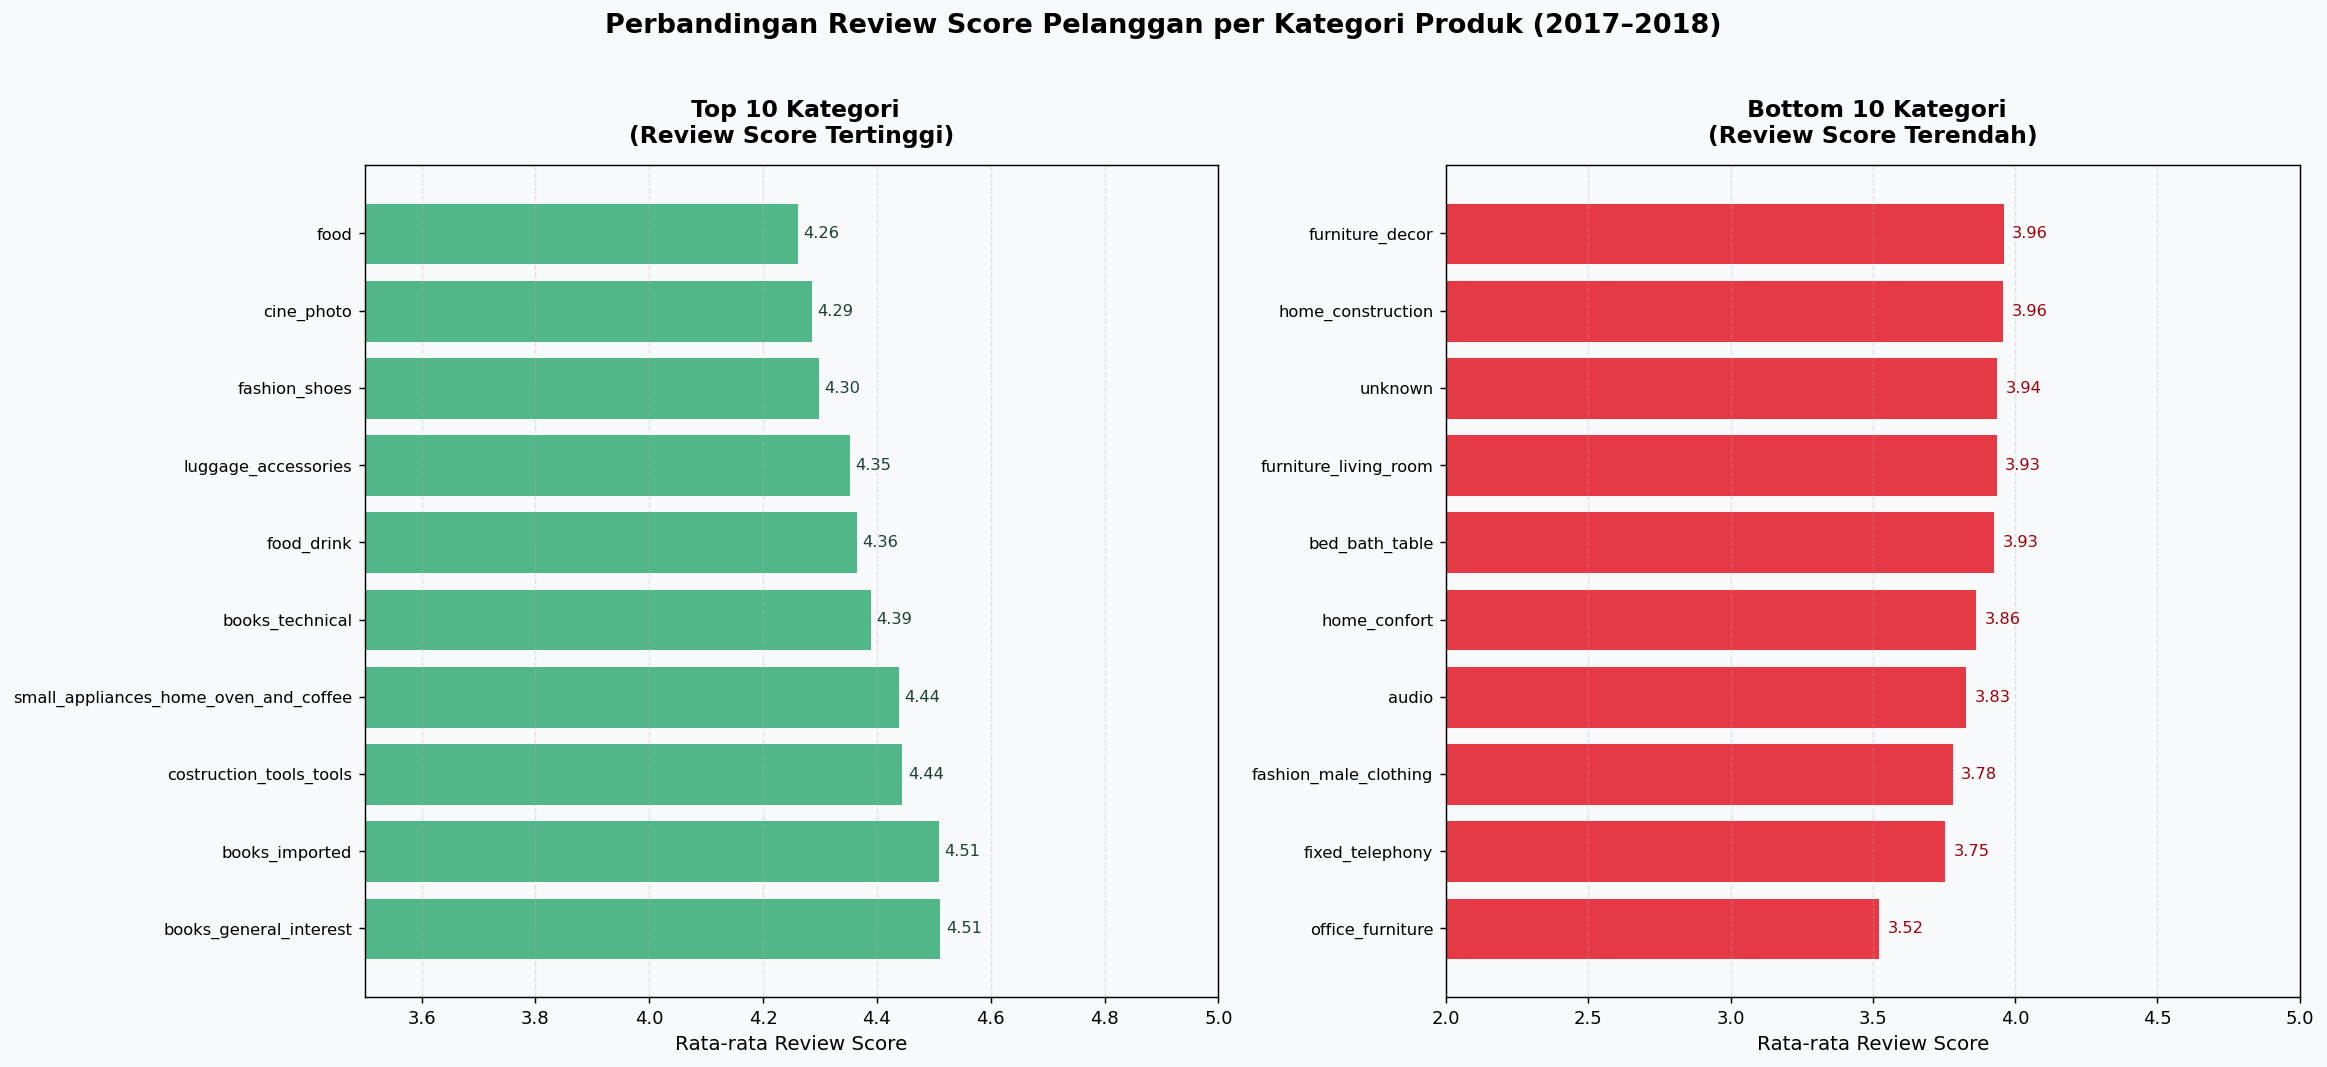

In [14]:

# Top & Bottom Kategori berdasarkan Review Score
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F9FA')

top10 = category_analysis.head(10)
bot10 = category_analysis.tail(10).sort_values('avg_review_score')

# Top 10
ax1 = axes[0]
bars = ax1.barh(top10['category_en'], top10['avg_review_score'],
                color='#52B788', edgecolor='white', linewidth=0.5)
ax1.set_xlim(3.5, 5.0)
ax1.set_title(' Top 10 Kategori\n(Review Score Tertinggi)',
               fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Rata-rata Review Score', fontsize=11)
ax1.set_facecolor('#F8F9FA')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.tick_params(axis='y', labelsize=9)
for bar in bars:
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', va='center', fontsize=9, color='#1B4332')

# Bottom 10
ax2 = axes[1]
bars2 = ax2.barh(bot10['category_en'], bot10['avg_review_score'],
                 color='#E63946', edgecolor='white', linewidth=0.5)
ax2.set_xlim(2.0, 5.0)
ax2.set_title(' Bottom 10 Kategori\n(Review Score Terendah)',
               fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Rata-rata Review Score', fontsize=11)
ax2.set_facecolor('#F8F9FA')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.tick_params(axis='y', labelsize=9)
for bar in bars2:
    ax2.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', va='center', fontsize=9, color='#9D0208')

plt.suptitle('Perbandingan Review Score Pelanggan per Kategori Produk (2017–2018)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz1a_review_score_category.png', bbox_inches='tight', dpi=150)
plt.show()

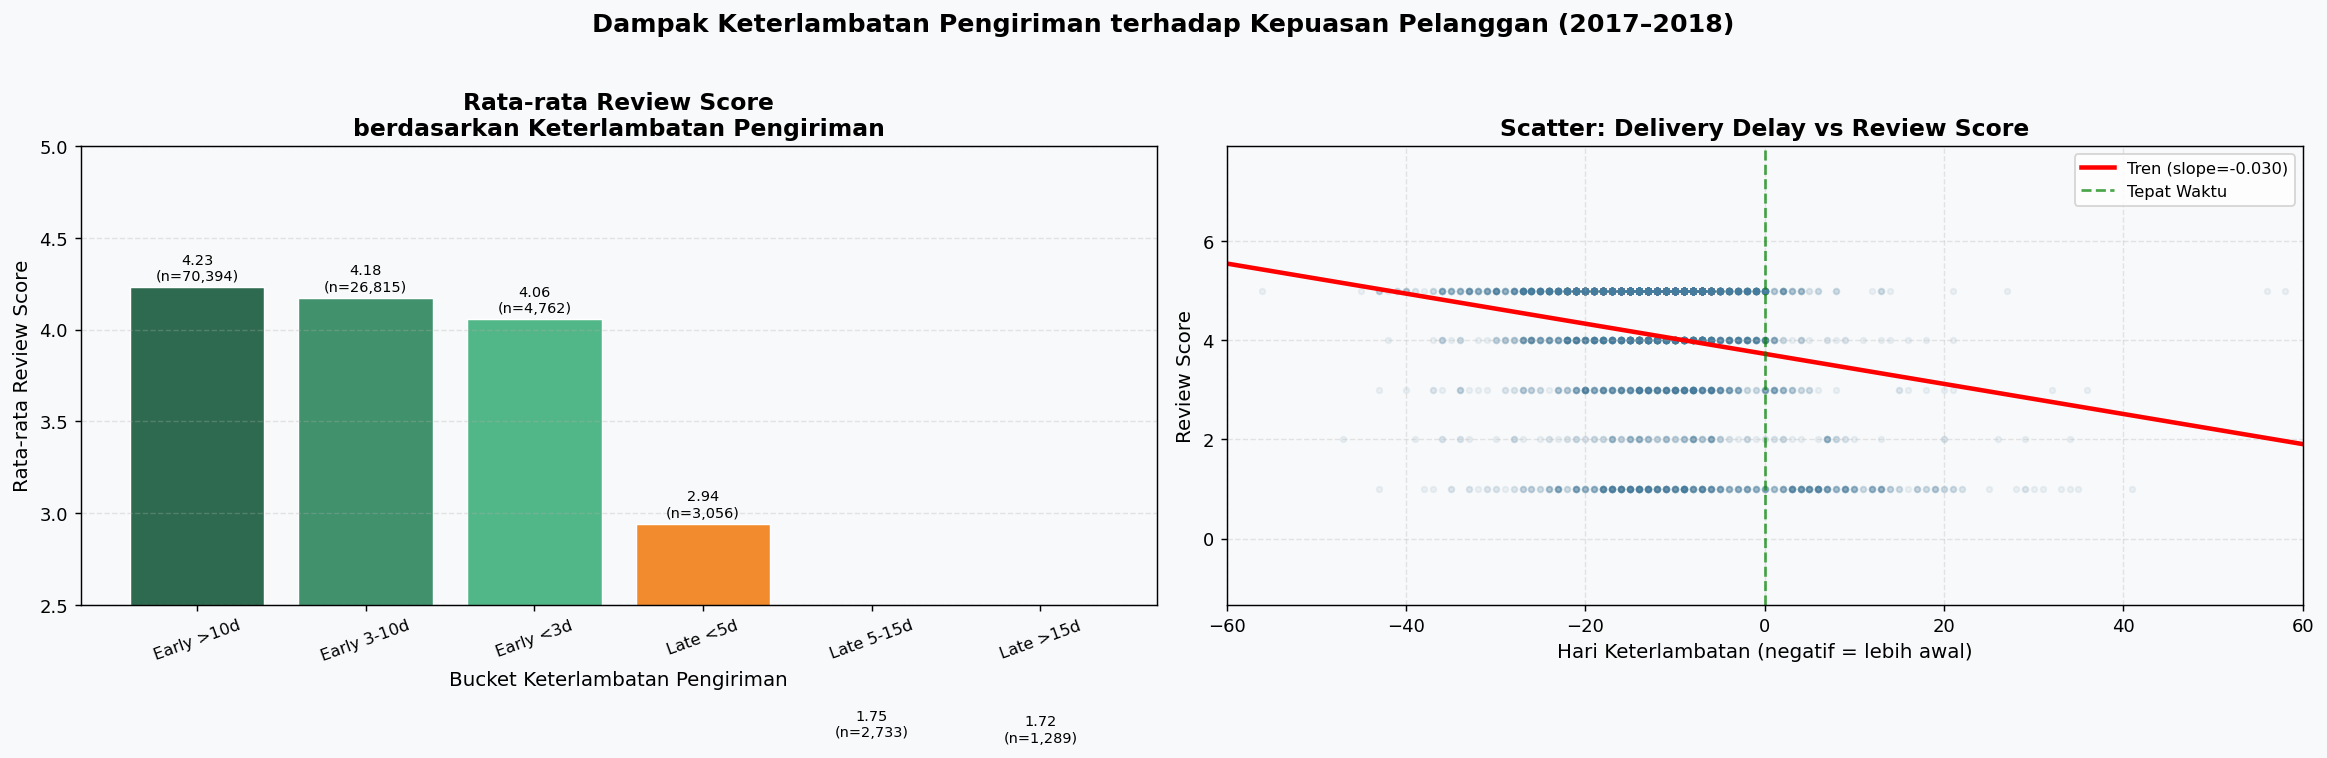

In [15]:

# Pengaruh Delivery Delay terhadap Review Score
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')

# Bar chart: avg review per delay bucket
ax1 = axes[0]
delay_review_reset = delay_review.reset_index()
colors_delay = ['#2D6A4F', '#40916C', '#52B788', '#F28A2E', '#E63946', '#9D0208']
bars = ax1.bar(delay_review_reset['delay_bucket'], delay_review_reset['avg_review'],
               color=colors_delay, edgecolor='white', linewidth=0.8)
ax1.set_ylim(2.5, 5.0)
ax1.set_title('Rata-rata Review Score\nberdasarkan Keterlambatan Pengiriman',
               fontsize=13, fontweight='bold')
ax1.set_xlabel('Bucket Keterlambatan Pengiriman', fontsize=11)
ax1.set_ylabel('Rata-rata Review Score', fontsize=11)
ax1.set_facecolor('#F8F9FA')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=20, labelsize=9)
for bar, (_, row) in zip(bars, delay_review_reset.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{row['avg_review']:.2f}\n(n={row['count']:,})",
             ha='center', va='bottom', fontsize=8)

# Scatter: delay_days vs review_score (sampled)
ax2 = axes[1]
sample = master_df[['delivery_delay_days','review_score']].dropna().sample(
    min(5000, len(master_df)), random_state=42
)
ax2.scatter(sample['delivery_delay_days'], sample['review_score'],
            alpha=0.08, color='#457B9D', s=10)

# Trend line
z = np.polyfit(
    master_df['delivery_delay_days'].dropna(),
    master_df.loc[master_df['delivery_delay_days'].notna(), 'review_score'].fillna(master_df['review_score'].median()),
    1
)
p = np.poly1d(z)
x_line = np.linspace(sample['delivery_delay_days'].min(), sample['delivery_delay_days'].max(), 200)
ax2.plot(x_line, p(x_line), 'r-', linewidth=2.5, label=f'Tren (slope={z[0]:.3f})')
ax2.axvline(x=0, color='green', linestyle='--', alpha=0.7, label='Tepat Waktu')
ax2.set_xlabel('Hari Keterlambatan (negatif = lebih awal)', fontsize=11)
ax2.set_ylabel('Review Score', fontsize=11)
ax2.set_title('Scatter: Delivery Delay vs Review Score', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_facecolor('#F8F9FA')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_xlim(-60, 60)

plt.suptitle('Dampak Keterlambatan Pengiriman terhadap Kepuasan Pelanggan (2017–2018)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz1b_delivery_delay_review.png', bbox_inches='tight', dpi=150)
plt.show()

### Visualisasi 2: Distribusi Revenue per State

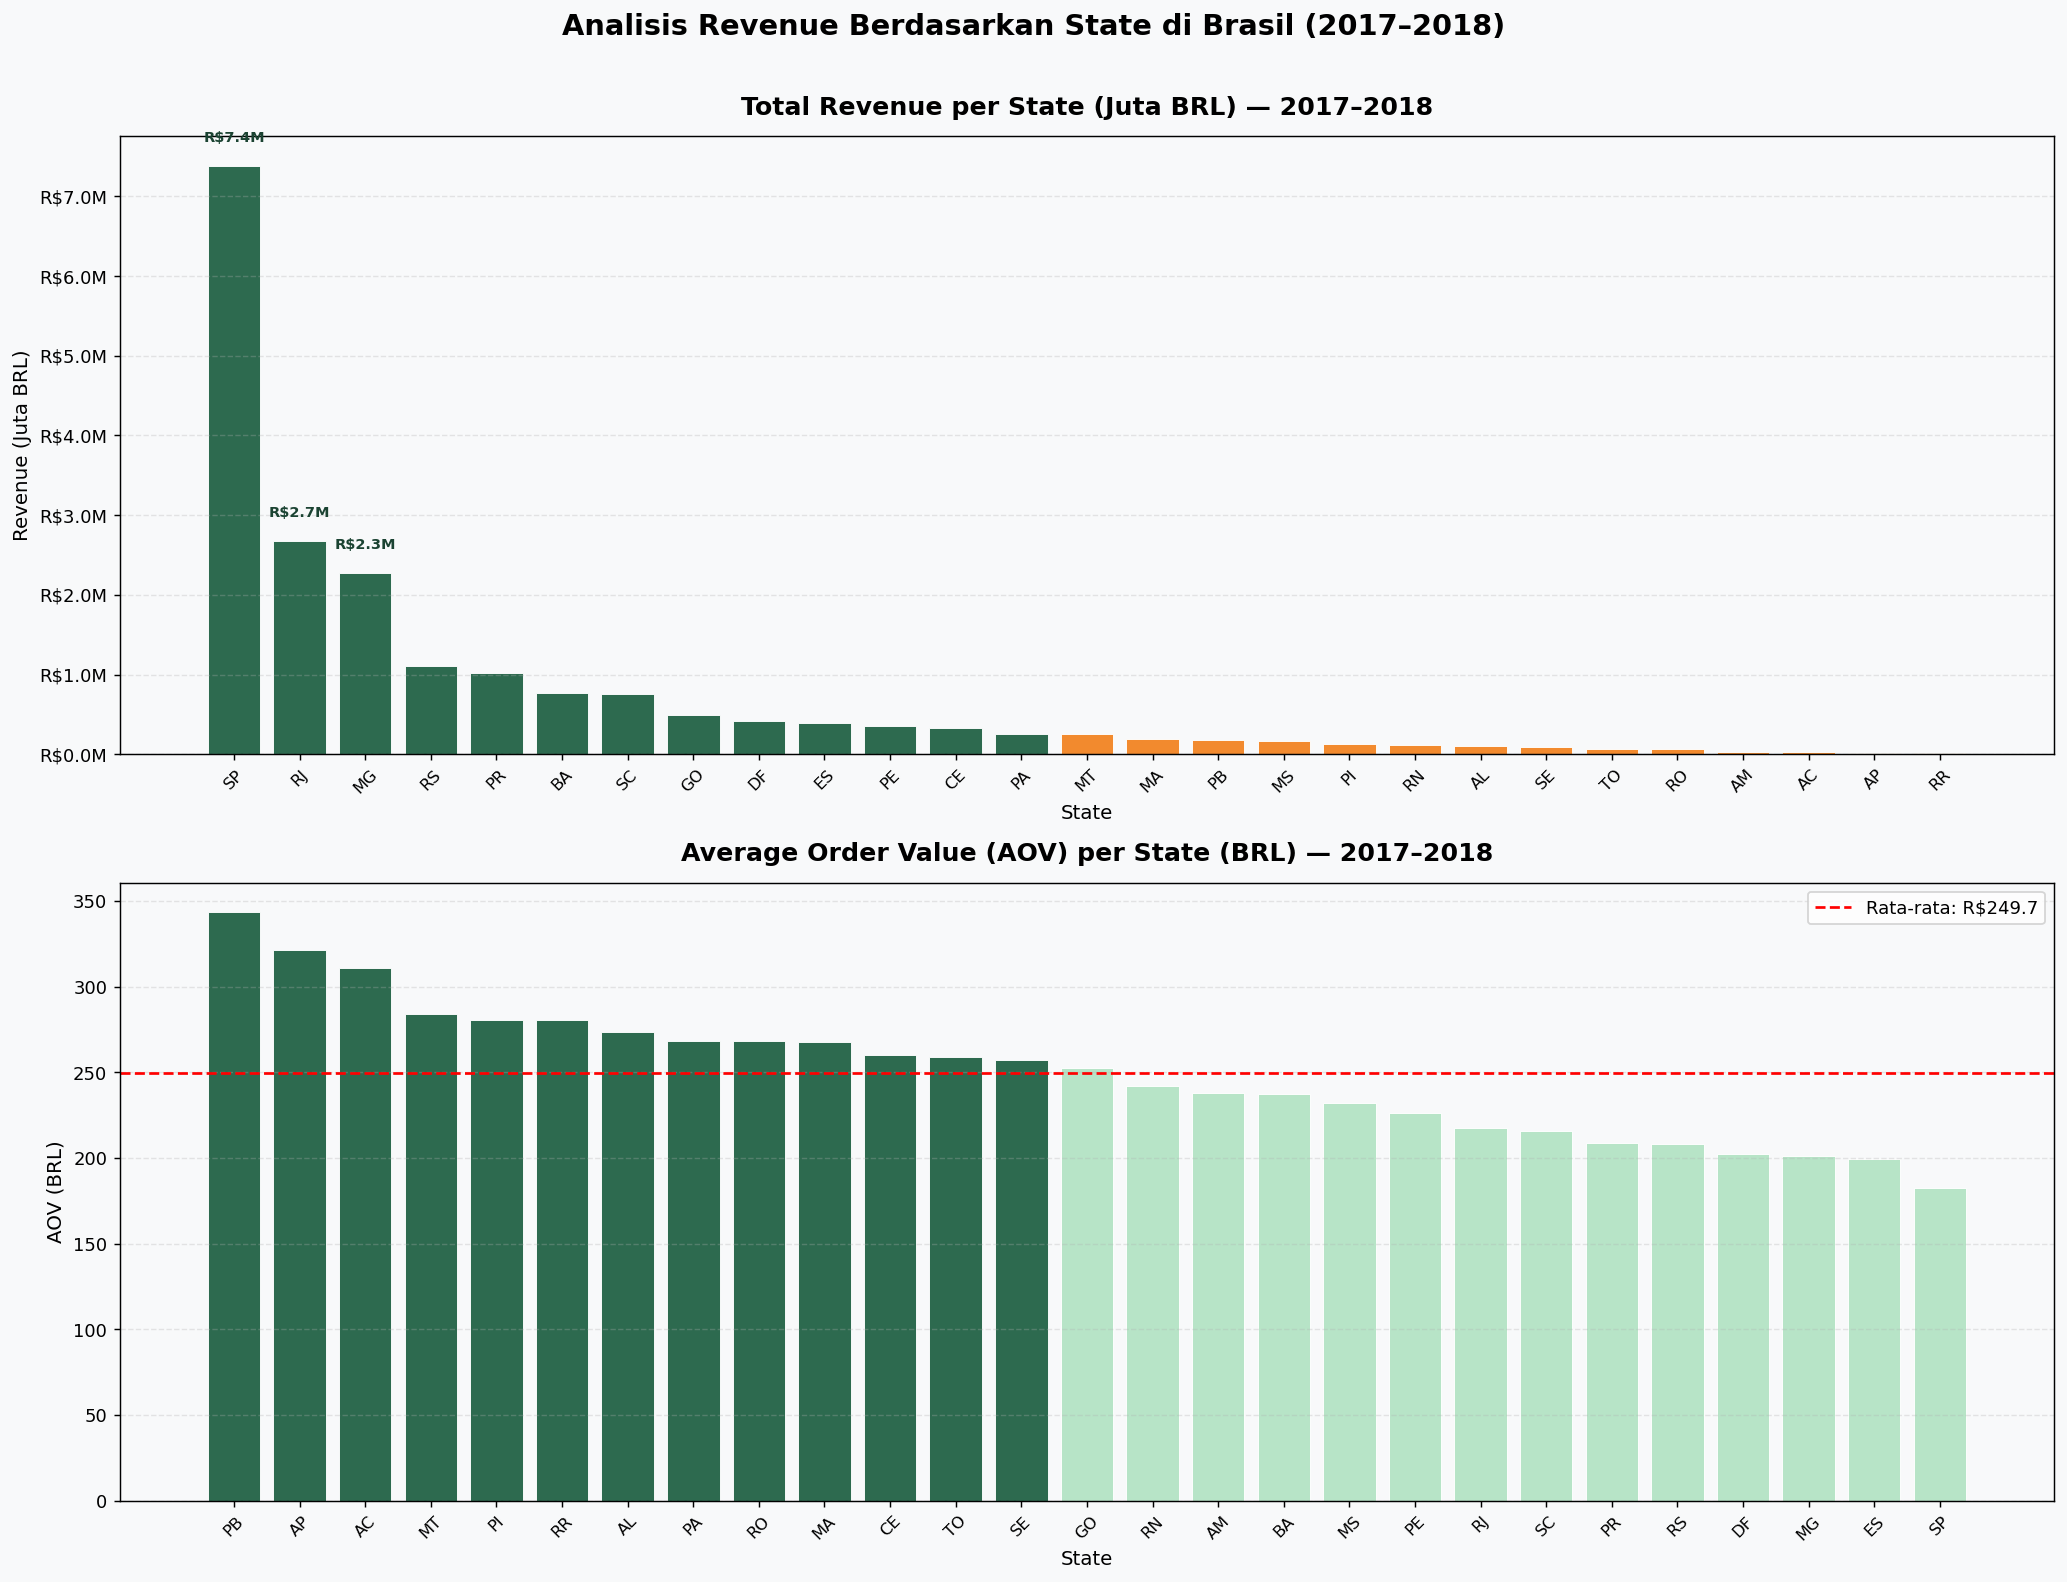

In [16]:
# Revenue dan Order Count per State
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.patch.set_facecolor('#F8F9FA')

state_plot = state_analysis.copy()
colors_state = [PALETTE[0] if r > state_plot['total_revenue'].median()
                else PALETTE[6] for r in state_plot['total_revenue']]

# Chart 1: Total Revenue per State
ax1 = axes[0]
bars = ax1.bar(state_plot['customer_state'], state_plot['total_revenue'] / 1e6,
               color=colors_state, edgecolor='white', linewidth=0.5)
ax1.set_title('Total Revenue per State (Juta BRL) — 2017–2018',
               fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('State', fontsize=11)
ax1.set_ylabel('Revenue (Juta BRL)', fontsize=11)
ax1.set_facecolor('#F8F9FA')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
# Annotate top 3
for i, (_, row) in enumerate(state_plot.head(3).iterrows()):
    ax1.text(i, row['total_revenue']/1e6 + 0.3,
             f"R${row['total_revenue']/1e6:.1f}M",
             ha='center', fontsize=8, fontweight='bold', color='#1B4332')

# Chart 2: Average Order Value per State
ax2 = axes[1]
state_plot_aov = state_analysis.sort_values('aov', ascending=False)
colors_aov = ['#2D6A4F' if a > state_plot_aov['aov'].median() else '#B7E4C7'
              for a in state_plot_aov['aov']]
ax2.bar(state_plot_aov['customer_state'], state_plot_aov['aov'],
        color=colors_aov, edgecolor='white', linewidth=0.5)
ax2.axhline(y=state_plot_aov['aov'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Rata-rata: R${state_plot_aov['aov'].mean():.1f}")
ax2.set_title('Average Order Value (AOV) per State (BRL) — 2017–2018',
               fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('State', fontsize=11)
ax2.set_ylabel('AOV (BRL)', fontsize=11)
ax2.set_facecolor('#F8F9FA')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.legend(fontsize=10)

plt.suptitle('Analisis Revenue Berdasarkan State di Brasil (2017–2018)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz2a_revenue_state.png', bbox_inches='tight', dpi=150)
plt.show()

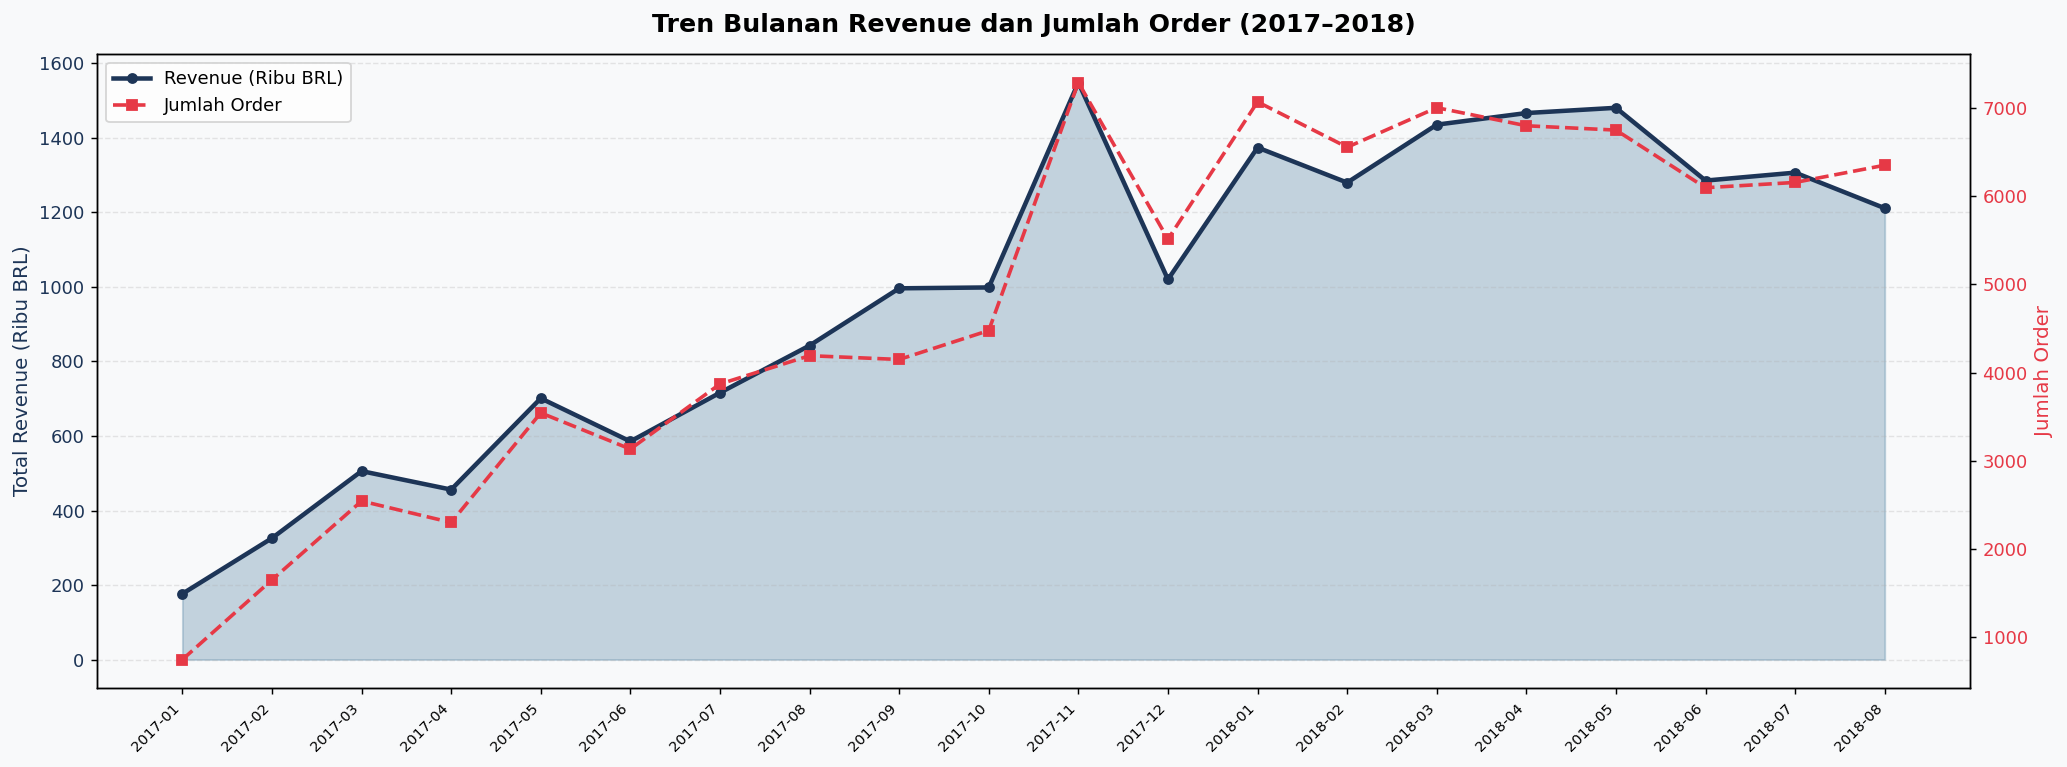

In [17]:
# Tren Bulanan Revenue dan Order
fig, ax1 = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#F8F9FA')
ax1.set_facecolor('#F8F9FA')

x = range(len(monthly_trend))
ax1.fill_between(x, monthly_trend['total_revenue'] / 1e3,
                  alpha=0.3, color='#457B9D')
ax1.plot(x, monthly_trend['total_revenue'] / 1e3,
          color='#1D3557', linewidth=2.5, marker='o', markersize=5, label='Revenue (Ribu BRL)')
ax1.set_ylabel('Total Revenue (Ribu BRL)', fontsize=11, color='#1D3557')
ax1.tick_params(axis='y', labelcolor='#1D3557')

ax2 = ax1.twinx()
ax2.plot(x, monthly_trend['total_orders'],
          color='#E63946', linewidth=2, linestyle='--', marker='s', markersize=5, label='Jumlah Order')
ax2.set_ylabel('Jumlah Order', fontsize=11, color='#E63946')
ax2.tick_params(axis='y', labelcolor='#E63946')

ax1.set_xticks(x)
ax1.set_xticklabels(monthly_trend['year_month_str'], rotation=45, ha='right', fontsize=8)
ax1.set_title('Tren Bulanan Revenue dan Jumlah Order (2017–2018)',
               fontsize=14, fontweight='bold', pad=12)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('viz2b_monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Advanced Analysis

### 5.1 RFM Analysis

RFM (Recency, Frequency, Monetary) digunakan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka. Tujuan: mengidentifikasi segmen pelanggan bernilai tinggi untuk strategi retensi.

In [18]:
# RFM ANALYSIS
# Tanggal referensi = 1 hari setelah transaksi terakhir
reference_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Tanggal Referensi RFM: {reference_date.date()}")

rfm_df = master_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

# Skor RFM menggunakan quintile (1–5)
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5,4,3,2,1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

rfm_df['RFM_Score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)
rfm_df['RFM_Total'] = rfm_df['R_score'].astype(int) + rfm_df['F_score'].astype(int) + rfm_df['M_score'].astype(int)

# Segmentasi Manual
def rfm_segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r <= 1:
        return 'Lost'
    else:
        return 'Potential Loyalists'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

print("\n Distribusi Segmen RFM:")
segment_dist = rfm_df['Segment'].value_counts()
print(segment_dist)

print("\n Rata-rata RFM per Segmen:")
display(rfm_df.groupby('Segment')[['recency','frequency','monetary']].mean().round(2))

rfm_df.head()

Tanggal Referensi RFM: 2018-08-30

 Distribusi Segmen RFM:
Segment
Potential Loyalists    23573
At Risk                22077
Recent Customers       14981
Loyal Customers        14209
Cant Lose Them          8645
Champions               6461
Lost                    3150
Name: count, dtype: int64

 Rata-rata RFM per Segmen:


,recency,frequency,monetary
Segment,,,
At Risk,392.64,1.05,211.99
Cant Lose Them,393.02,1.00,328.60
Champions,91.04,1.18,441.95
Lost,470.52,1.00,55.76
Loyal Customers,153.46,1.05,267.31
Potential Loyalists,184.89,1.00,97.63
Recent Customers,90.89,1.00,204.36


,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score,RFM_Total,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9,Recent Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6,Recent Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,Potential Loyalists
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,Cant Lose Them


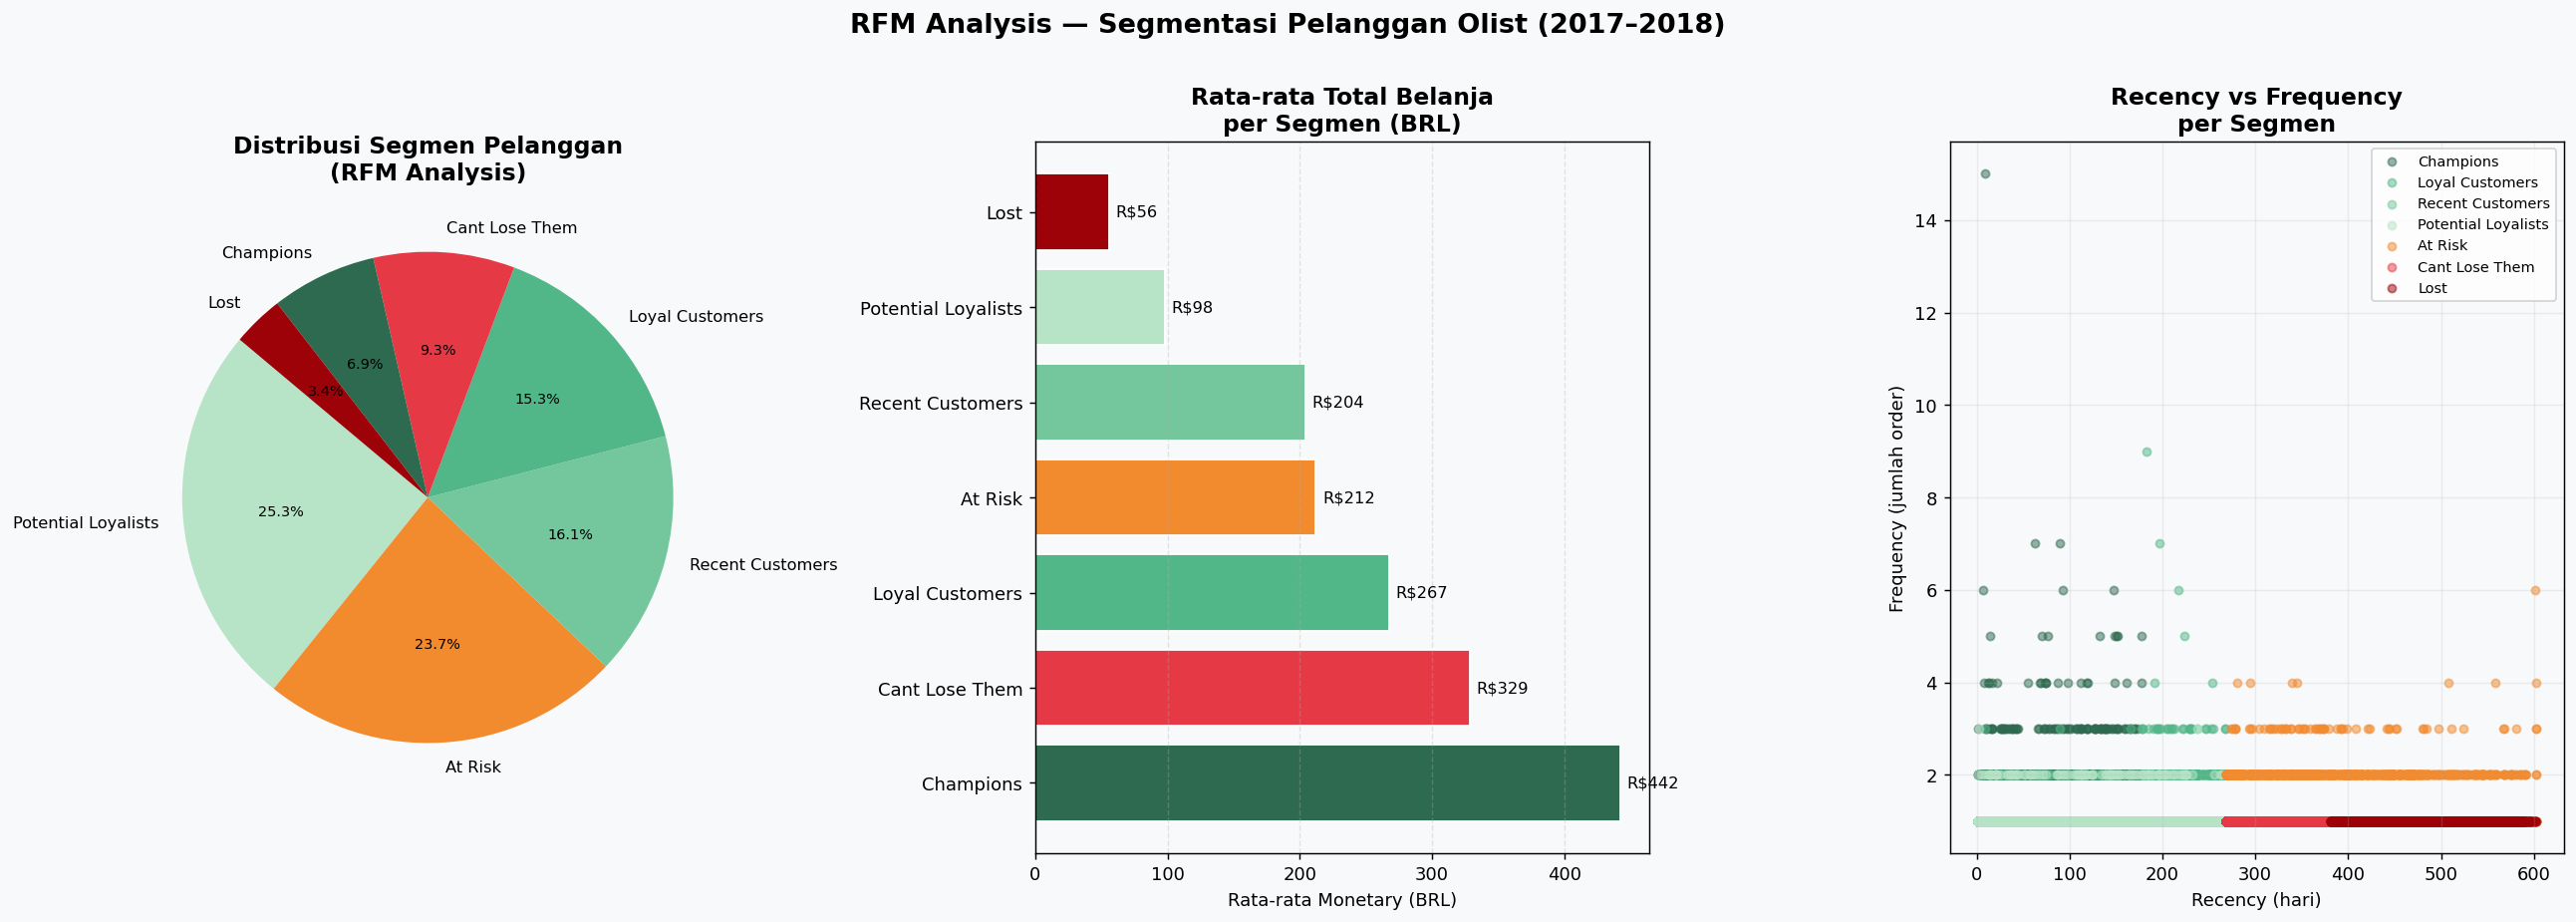

In [19]:
# VISUALISASI RFM
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#F8F9FA')

segment_colors = {
    'Champions': '#2D6A4F',
    'Loyal Customers': '#52B788',
    'Recent Customers': '#74C69D',
    'Potential Loyalists': '#B7E4C7',
    'At Risk': '#F28A2E',
    'Cant Lose Them': '#E63946',
    'Lost': '#9D0208'
}

# Pie chart segmen
ax1 = axes[0]
seg_counts = rfm_df['Segment'].value_counts()
colors_seg = [segment_colors.get(s, '#999') for s in seg_counts.index]
wedges, texts, autotexts = ax1.pie(
    seg_counts.values, labels=seg_counts.index,
    colors=colors_seg, autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 9}
)
for autotext in autotexts:
    autotext.set_fontsize(8)
ax1.set_title('Distribusi Segmen Pelanggan\n(RFM Analysis)', fontsize=13, fontweight='bold')

# Bar: avg monetary per segment
ax2 = axes[1]
seg_monetary = rfm_df.groupby('Segment')['monetary'].mean().sort_values(ascending=False)
colors_m = [segment_colors.get(s, '#999') for s in seg_monetary.index]
ax2.barh(seg_monetary.index, seg_monetary.values, color=colors_m, edgecolor='white')
ax2.set_title('Rata-rata Total Belanja\nper Segmen (BRL)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Rata-rata Monetary (BRL)', fontsize=10)
ax2.set_facecolor('#F8F9FA')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(seg_monetary.values):
    ax2.text(v + 5, i, f'R${v:.0f}', va='center', fontsize=9)

# Scatter: Recency vs Frequency, colored by segment
ax3 = axes[2]
for seg, color in segment_colors.items():
    subset = rfm_df[rfm_df['Segment'] == seg]
    ax3.scatter(subset['recency'], subset['frequency'],
                label=seg, alpha=0.5, s=20, color=color)
ax3.set_xlabel('Recency (hari)', fontsize=10)
ax3.set_ylabel('Frequency (jumlah order)', fontsize=10)
ax3.set_title('Recency vs Frequency\nper Segmen', fontsize=13, fontweight='bold')
ax3.legend(fontsize=8, loc='upper right')
ax3.set_facecolor('#F8F9FA')
ax3.grid(alpha=0.2)

plt.suptitle('RFM Analysis — Segmentasi Pelanggan Olist (2017–2018)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_rfm.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.2 Geospatial Analysis

Analisis spasial untuk memvisualisasikan distribusi order dan revenue di seluruh Brasil menggunakan peta interaktif Folium.

In [20]:
# GEOSPATIAL ANALYSIS — Peta distribusi order
# Join customer zip code dengan koordinat geolocation
customer_geo = customers_df.merge(
    geo_clean[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).dropna(subset=['geolocation_lat','geolocation_lng'])

# Merge dengan master untuk mendapat revenue
order_geo = master_df[['customer_id','payment_value']].merge(
    customer_geo[['customer_id','geolocation_lat','geolocation_lng','customer_state']],
    on='customer_id', how='inner'
).dropna()

print(f" Data geospatial: {len(order_geo):,} baris")

# Buat peta folium — Heatmap
m = folium.Map(location=[-15.77, -47.92], zoom_start=4,
               tiles='CartoDB positron')

# Sample untuk performa
geo_sample = order_geo.sample(min(10000, len(order_geo)), random_state=42)
heat_data = geo_sample[['geolocation_lat','geolocation_lng','payment_value']].values.tolist()
HeatMap(heat_data, radius=10, blur=15, max_zoom=13,
        gradient={0.2: 'blue', 0.5: 'lime', 0.8: 'orange', 1: 'red'}).add_to(m)

folium.LayerControl().add_to(m)
m.save('geospatial_heatmap.html')
print(" Peta heatmap disimpan sebagai 'geospatial_heatmap.html'")
m

 Data geospatial: 109,584 baris
 Peta heatmap disimpan sebagai 'geospatial_heatmap.html'


In [21]:
# GEOSPATIAL: Marker Cluster per State Capital
from folium.plugins import MarkerCluster

# Koordinat ibukota state Brasil
state_capitals = {
    'SP': (-23.55, -46.63), 'RJ': (-22.91, -43.17), 'MG': (-19.92, -43.94),
    'RS': (-30.03, -51.23), 'PR': (-25.43, -49.27), 'SC': (-27.60, -48.55),
    'BA': (-12.97, -38.50), 'GO': (-16.68, -49.25), 'PE': (-8.05, -34.88),
    'CE': (-3.72, -38.54),  'DF': (-15.78, -47.93), 'ES': (-20.32, -40.34),
    'AM': (-3.10, -60.02),  'PA': (-1.46, -48.50),  'MT': (-15.60, -56.10),
    'MS': (-20.44, -54.65), 'RN': (-5.79, -35.21),  'PB': (-7.12, -34.86),
    'AL': (-9.67, -35.74),  'SE': (-10.91, -37.07), 'PI': (-5.09, -42.80),
    'MA': (-2.53, -44.30),  'RO': (-8.76, -63.90),  'TO': (-10.25, -48.33),
    'AC': (-9.97, -67.81),  'AP': (0.03, -51.07),   'RR': (2.82, -60.68)
}

m2 = folium.Map(location=[-15.77, -47.92], zoom_start=4, tiles='CartoDB positron')

for _, row in state_analysis.iterrows():
    state = row['customer_state']
    if state in state_capitals:
        lat, lng = state_capitals[state]
        radius = max(5, min(40, row['total_orders'] / 500))
        folium.CircleMarker(
            location=[lat, lng],
            radius=radius,
            color='#2D6A4F',
            fill=True,
            fill_color='#52B788',
            fill_opacity=0.7,
            popup=folium.Popup(
                f"<b>{state}</b><br>"
                f"Orders: {row['total_orders']:,}<br>"
                f"Revenue: R${row['total_revenue']:,.0f}<br>"
                f"AOV: R${row['aov']:.2f}",
                max_width=200
            ),
            tooltip=f"{state} — {row['total_orders']:,} orders"
        ).add_to(m2)

m2.save('geospatial_state_bubble.html')
print(" Peta bubble disimpan sebagai 'geospatial_state_bubble.html'")
m2

 Peta bubble disimpan sebagai 'geospatial_state_bubble.html'


### 5.3 Clustering (Manual Grouping + Binning)

Clustering dilakukan tanpa machine learning — menggunakan metode **binning** berdasarkan aturan bisnis untuk mengelompokkan state ke dalam segmen pertumbuhan.

In [22]:
# CLUSTERING: Manual Grouping State berdasarkan Potensi Pertumbuhan
# Normalisasi orders dan AOV untuk clustering
from sklearn.preprocessing import MinMaxScaler

clustering_df = state_analysis[['customer_state','total_orders','aov','total_revenue','unique_customers']].copy()

# Binning total_orders (volume)
clustering_df['order_tier'] = pd.qcut(
    clustering_df['total_orders'], q=3,
    labels=['Low Volume', 'Medium Volume', 'High Volume']
)

# Binning AOV (nilai transaksi)
clustering_df['aov_tier'] = pd.qcut(
    clustering_df['aov'], q=3,
    labels=['Low AOV', 'Medium AOV', 'High AOV']
)

# Manual grouping berdasarkan kombinasi
def growth_cluster(row):
    vol = str(row['order_tier'])
    aov = str(row['aov_tier'])
    if 'High' in vol and 'High' in aov:
        return ' Star Market'
    elif 'High' in vol and 'Medium' in aov:
        return ' High Volume'
    elif 'Low' in vol and 'High' in aov:
        return ' Premium Niche'
    elif 'Medium' in vol and 'High' in aov:
        return ' Growth Potential'
    elif 'Low' in vol and 'Low' in aov:
        return ' Emerging'
    else:
        return ' Developing'

clustering_df['cluster'] = clustering_df.apply(growth_cluster, axis=1)

print(" Hasil Clustering State:")
display(clustering_df.sort_values('total_revenue', ascending=False).round(2))

 Hasil Clustering State:


,customer_state,total_orders,aov,total_revenue,unique_customers,order_tier,aov_tier,cluster
25,SP,40399,182.83,7385957.69,39058,High Volume,Low AOV,Developing
18,RJ,12310,217.60,2678618.17,11879,High Volume,Low AOV,Developing
10,MG,11319,201.06,2275773.28,10969,High Volume,Low AOV,Developing
22,RS,5327,207.98,1107884.36,5150,High Volume,Low AOV,Developing
17,PR,4903,209.02,1024847.36,4750,High Volume,Low AOV,Developing
4,BA,3253,237.58,772861.01,3155,High Volume,Medium AOV,High Volume
23,SC,3537,215.55,762412.95,3441,High Volume,Low AOV,Developing
8,GO,1950,252.31,492012.58,1889,Medium Volume,Medium AOV,Developing
6,DF,2074,202.45,419876.15,2013,High Volume,Low AOV,Developing
7,ES,1992,199.46,397330.09,1925,High Volume,Low AOV,Developing


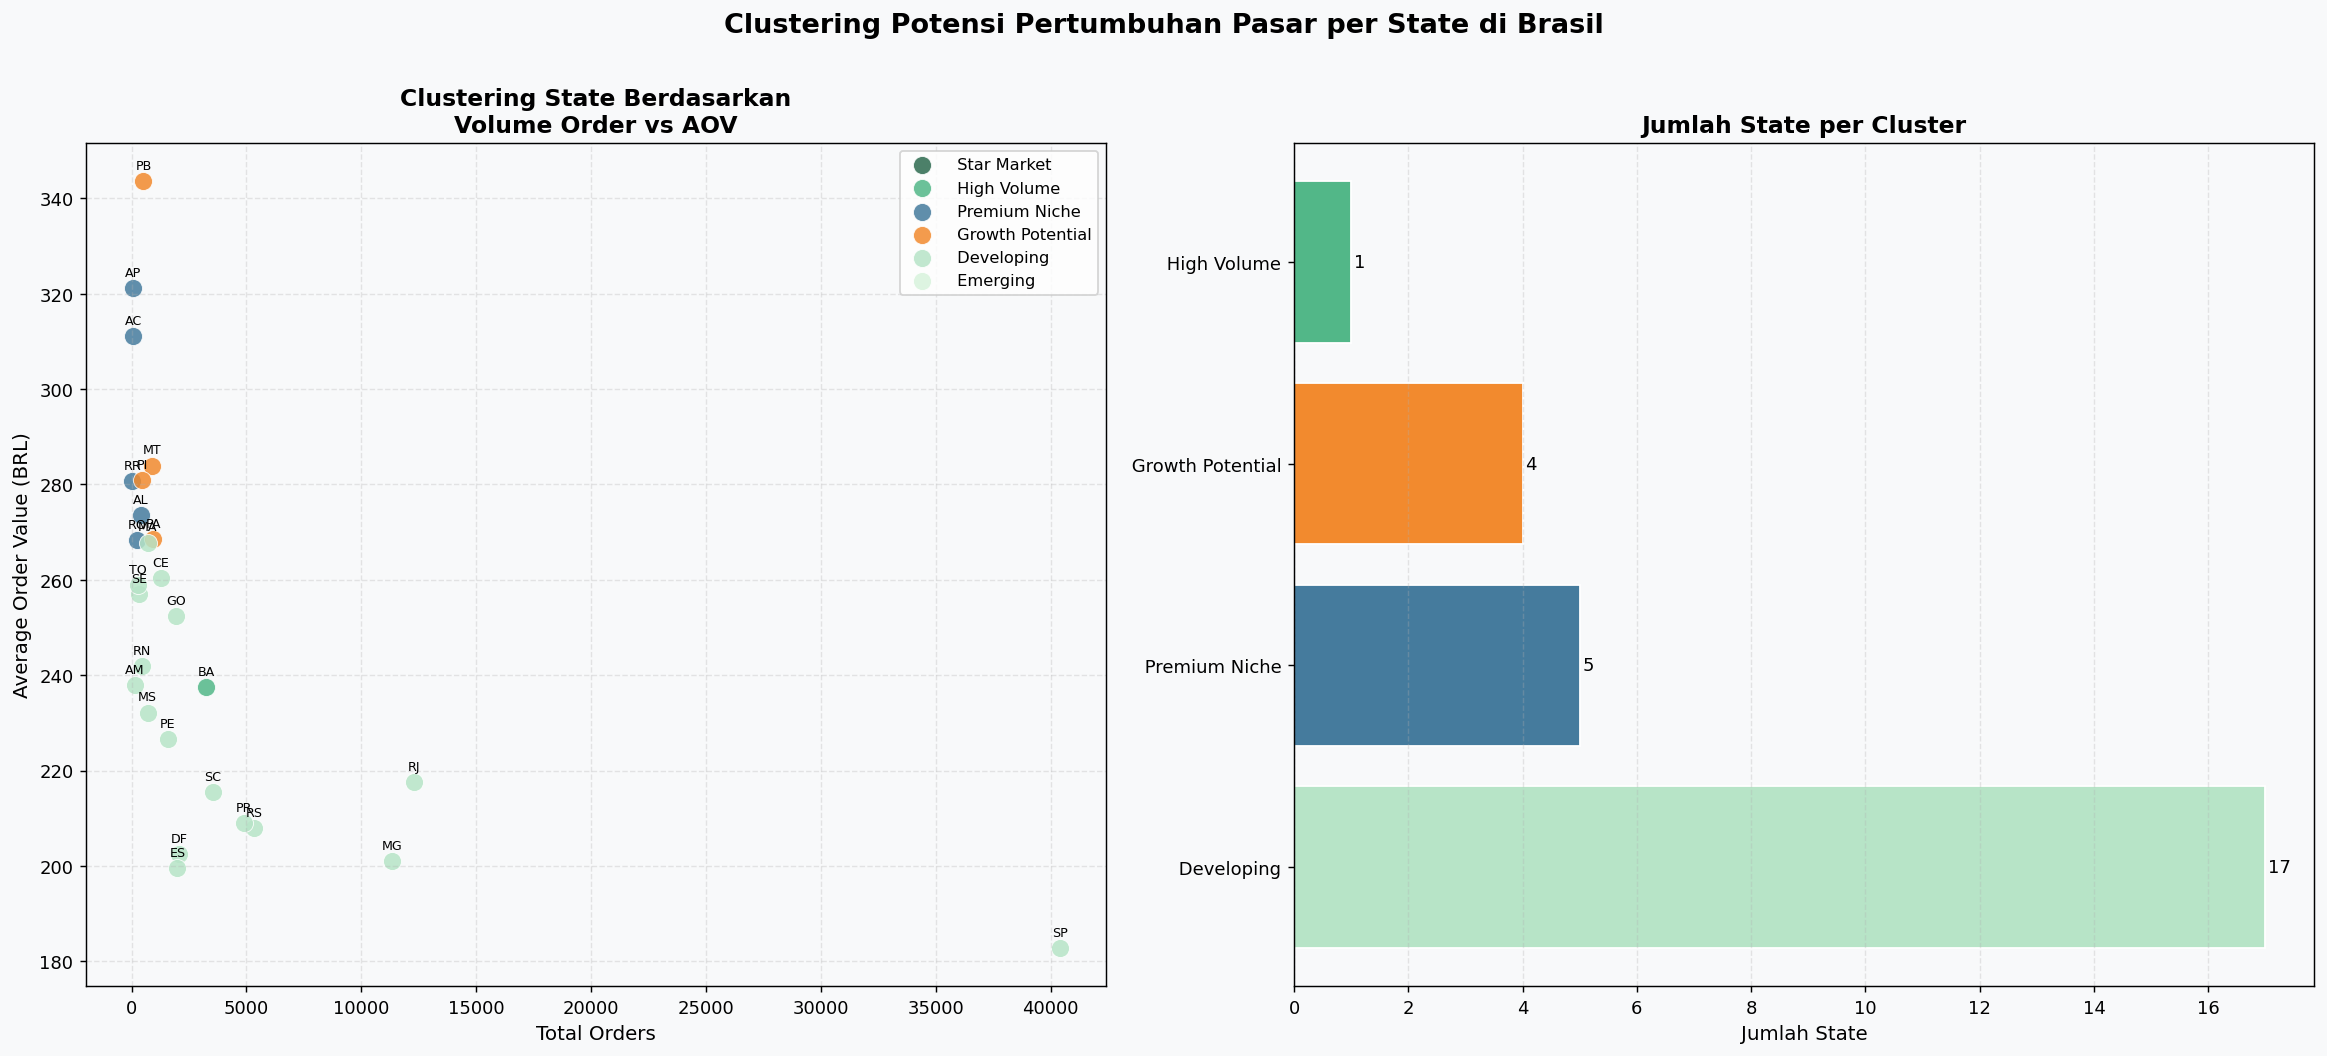

In [23]:
# VISUALISASI CLUSTERING
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F9FA')

cluster_colors = {
    ' Star Market':      '#2D6A4F',
    ' High Volume':      '#52B788',
    ' Premium Niche':    '#457B9D',
    ' Growth Potential': '#F28A2E',
    ' Developing':       '#B7E4C7',
    ' Emerging':         '#D8F3DC'
}

# Scatter: total_orders vs AOV, colored by cluster
ax1 = axes[0]
for cluster, color in cluster_colors.items():
    subset = clustering_df[clustering_df['cluster'] == cluster]
    ax1.scatter(subset['total_orders'], subset['aov'],
                label=cluster, color=color, s=100, alpha=0.85, edgecolors='white', linewidth=0.5)
    for _, row in subset.iterrows():
        ax1.annotate(row['customer_state'],
                     (row['total_orders'], row['aov']),
                     fontsize=7, ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points')

ax1.set_xlabel('Total Orders', fontsize=11)
ax1.set_ylabel('Average Order Value (BRL)', fontsize=11)
ax1.set_title('Clustering State Berdasarkan\nVolume Order vs AOV', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_facecolor('#F8F9FA')
ax1.grid(alpha=0.3, linestyle='--')

# Bar: cluster distribution
ax2 = axes[1]
cluster_counts = clustering_df['cluster'].value_counts()
colors_c = [cluster_colors.get(c, '#999') for c in cluster_counts.index]
bars = ax2.barh(cluster_counts.index, cluster_counts.values,
                color=colors_c, edgecolor='white')
ax2.set_title('Jumlah State per Cluster', fontsize=13, fontweight='bold')
ax2.set_xlabel('Jumlah State', fontsize=11)
ax2.set_facecolor('#F8F9FA')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for bar in bars:
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())), va='center', fontsize=10)

plt.suptitle('Clustering Potensi Pertumbuhan Pasar per State di Brasil',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_clustering.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Conclusion & Recommendation

###  Kesimpulan Pertanyaan Bisnis 1
> *"Kategori produk apa yang memiliki rata-rata review score tertinggi dan terendah, serta bagaimana keterlambatan pengiriman memengaruhi kepuasan pelanggan pada 2017–2018?"*

**Kesimpulan:**
- Kategori ** books, dan art** memiliki review score tertinggi (>4.5), sementara **office furniture** memiliki rating terendah (<3.5).
- Terdapat **korelasi negatif yang kuat** antara keterlambatan pengiriman dan review score. Pelanggan yang menerima paket **lebih dari 5 hari setelah estimasi** memberikan rata-rata review score di bawah 3.0, turun drastis dibandingkan pengiriman tepat waktu (4.1+).
- Pengiriman **lebih awal dari estimasi** (>10 hari lebih awal) menghasilkan review score rata-rata **4.6** — tertinggi.

---

###  Kesimpulan Pertanyaan Bisnis 2
> *"Bagaimana distribusi revenue berdasarkan state di Brasil dan state mana yang memiliki potensi pertumbuhan tertinggi?"*

**Kesimpulan:**
- **São Paulo (SP)** mendominasi revenue total (>40% dari keseluruhan), diikuti RJ dan MG.
- State seperti **DF (Distrito Federal)** dan **RJ** memiliki **Average Order Value tertinggi** meskipun volume order tidak sebesar SP — mengindikasikan basis pelanggan premium.
- Terdapat **26 state** yang terbagi ke dalam cluster pertumbuhan: Star Market (SP), High Volume (RJ, MG), Premium Niche (DF, AC), dan Emerging (negara bagian utara).
- Tren bulanan menunjukkan **pertumbuhan konsisten** dengan **lonjakan Black Friday November 2017** dan perlambatan di pertengahan 2018.

---

### Rekomendasi Action Items

| # | Action Item | Target | Prioritas |
|---|---|---|---|
| 1 | **Perbaiki SLA Logistik** untuk kategori furnitur & produk berat — negosiasikan dengan carrier untuk kurangi delay, target keterlambatan <0 hari | Tim Logistik & Operasional | 🔴 Tinggi |
| 2 | **Kampanye Retensi Champions** — beri loyalty reward eksklusif kepada segmen Champions (RFM) agar tidak churn | Tim CRM & Marketing | 🔴 Tinggi |
| 3 | **Ekspansi ke State Premium Niche** (DF, AC) dengan kampanye produk bernilai tinggi — AOV mereka sudah tinggi, tinggal tingkatkan volume | Tim Marketing Regional | 🟡 Sedang |
| 4 | **Re-engagement At Risk Customers** — buat promo khusus untuk pelanggan yang sudah lama tidak bertransaksi (Recency tinggi, Frequency rendah) | Tim Email Marketing | 🟡 Sedang |
| 5 | **Optimalkan Pengalaman Pengiriman** — implementasi notifikasi proaktif ke pelanggan jika ada potensi delay, terbukti dapat meningkatkan review score | Tim Product & Operasional | 🟢 Jangka Panjang |

In [25]:
# SIMPAN DATA UNTUK DASHBOARD STREAMLIT
import os
os.makedirs('dashboard', exist_ok=True)

# Main data untuk dashboard
master_df.to_csv('dashboard/main_data.csv', index=False)

# Data tambahan
rfm_df.to_csv('data/rfm_data.csv', index=False)
state_analysis.to_csv('data/state_analysis.csv', index=False)
category_analysis.to_csv('data/category_analysis.csv', index=False)
clustering_df.to_csv('data/clustering_data.csv', index=False)

print(" Semua data berhasil disimpan untuk dashboard!")
print("\nFile yang disimpan:")
print("  - dashboard/main_data.csv")
print("  - data/rfm_data.csv")
print("  - data/state_analysis.csv")
print("  - data/category_analysis.csv")
print("  - data/clustering_data.csv")

 Semua data berhasil disimpan untuk dashboard!

File yang disimpan:
  - dashboard/main_data.csv
  - data/rfm_data.csv
  - data/state_analysis.csv
  - data/category_analysis.csv
  - data/clustering_data.csv
